# Step 2: Eksplorasi Data (EDA)

Replikasi Tabel 2 (ringkasan fitur numerik) dan Tabel 3 (ringkasan fitur kategorikal) dari paper.

Fitur numerik (10): Administrative, Administrative_Duration, Informational, Informational_Duration, ProductRelated, ProductRelated_Duration, BounceRates, ExitRates, PageValues, SpecialDay

Fitur kategorikal (7): OperatingSystems, Browser, Region, TrafficType, VisitorType, Weekend, Month

In [1]:
import sys, os
sys.path.append('../src')
from data_utils import load_data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('../results/tables', exist_ok=True)
os.makedirs('../results/figures', exist_ok=True)

df = load_data()
df.shape

(12330, 18)

## Distribusi Kelas Revenue

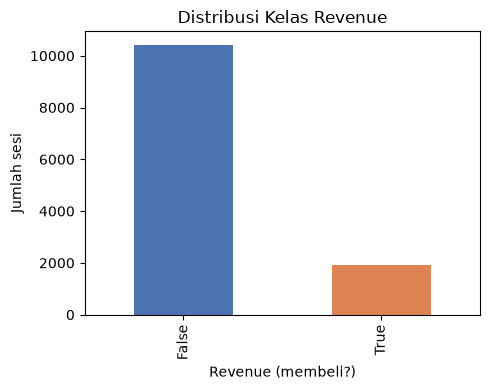

In [2]:
fig, ax = plt.subplots(figsize=(5,4))
df['Revenue'].value_counts().plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title('Distribusi Kelas Revenue')
ax.set_xlabel('Revenue (membeli?)')
ax.set_ylabel('Jumlah sesi')
plt.tight_layout()
plt.savefig('../results/figures/class_distribution.png', dpi=120)
plt.show()

## Ringkasan Fitur Numerik (replikasi Tabel 2)

In [3]:
numeric_features = [
    'Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay'
]

numeric_summary = pd.DataFrame({
    'min': df[numeric_features].min(),
    'max': df[numeric_features].max(),
    'mean': df[numeric_features].mean(),
    'std': df[numeric_features].std(),
})
numeric_summary = numeric_summary.round(2)
numeric_summary.to_csv('../results/tables/eda_numeric_summary.csv')
numeric_summary

,min,max,mean,std
Administrative,0.0,27.00,2.32,3.32
Administrative_Duration,0.0,3398.75,80.82,176.78
Informational,0.0,24.00,0.50,1.27
Informational_Duration,0.0,2549.38,34.47,140.75
ProductRelated,0.0,705.00,31.73,44.48
ProductRelated_Duration,0.0,63973.52,1194.75,1913.67
BounceRates,0.0,0.20,0.02,0.05
ExitRates,0.0,0.20,0.04,0.05
PageValues,0.0,361.76,5.89,18.57
SpecialDay,0.0,1.00,0.06,0.20


Bandingkan dengan Tabel 2 paper (std dari beberapa fitur, dibaca dari teks paper):
- Administrative_Duration: max=3398, std=176.70
- Content(Informational)_Duration: max=2549, std=140.64
- Product pages (ProductRelated): max=705, std=44.45
- Product pages duration: max=63973, std=1912.25
- Bounce rate: max=0.2, std=0.04
- Exit rate: max=0.2, std=0.05
- Page value: max=361, std=18.55
- Special day: max=1.0, std=0.19

In [4]:
paper_table2 = {
    'Administrative_Duration': {'max': 3398, 'std': 176.70},
    'Informational_Duration': {'max': 2549, 'std': 140.64},
    'ProductRelated': {'max': 705, 'std': 44.45},
    'ProductRelated_Duration': {'max': 63973, 'std': 1912.25},
    'BounceRates': {'max': 0.2, 'std': 0.04},
    'ExitRates': {'max': 0.2, 'std': 0.05},
    'PageValues': {'max': 361, 'std': 18.55},
    'SpecialDay': {'max': 1.0, 'std': 0.19},
}

print(f"{'Fitur':<28}{'Max Kita':>10}{'Max Paper':>12}{'Std Kita':>10}{'Std Paper':>12}")
for feat, vals in paper_table2.items():
    max_us = numeric_summary.loc[feat, 'max']
    std_us = numeric_summary.loc[feat, 'std']
    print(f"{feat:<28}{max_us:>10}{vals['max']:>12}{std_us:>10}{vals['std']:>12}")

Fitur                         Max Kita   Max Paper  Std Kita   Std Paper
Administrative_Duration        3398.75        3398    176.78       176.7
Informational_Duration         2549.38        2549    140.75      140.64
ProductRelated                   705.0         705     44.48       44.45
ProductRelated_Duration       63973.52       63973   1913.67     1912.25
BounceRates                        0.2         0.2      0.05        0.04
ExitRates                          0.2         0.2      0.05        0.05
PageValues                      361.76         361     18.57       18.55
SpecialDay                         1.0         1.0       0.2        0.19


## Ringkasan Fitur Kategorikal (replikasi Tabel 3)

In [5]:
categorical_features = ['OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Month']

cat_summary = pd.DataFrame({
    'n_levels': [df[c].nunique() for c in categorical_features],
}, index=categorical_features)
cat_summary.to_csv('../results/tables/eda_categorical_summary.csv')
cat_summary

,n_levels
OperatingSystems,8
Browser,13
Region,9
TrafficType,20
VisitorType,3
Weekend,2
Month,10


Bandingkan dengan Tabel 3 paper (jumlah level):
- OperatingSystems: 8
- Browser: 13
- Region (disebut 'Location' di paper): 9
- TrafficType: 20
- VisitorType: 3
- Weekend: 2
- Month: 12

In [6]:
paper_table3 = {
    'OperatingSystems': 8, 'Browser': 13, 'Region': 9, 'TrafficType': 20,
    'VisitorType': 3, 'Weekend': 2, 'Month': 12
}

print(f"{'Fitur':<20}{'Levels Kita':>14}{'Levels Paper':>16}{'Match?':>10}")
for feat, expected in paper_table3.items():
    actual = cat_summary.loc[feat, 'n_levels']
    match = 'OK' if actual == expected else 'CEK'
    print(f"{feat:<20}{actual:>14}{expected:>16}{match:>10}")

Fitur                  Levels Kita    Levels Paper    Match?
OperatingSystems                 8               8        OK
Browser                         13              13        OK
Region                           9               9        OK
TrafficType                     20              20        OK
VisitorType                      3               3        OK
Weekend                          2               2        OK
Month                           10              12       CEK


### Catatan Temuan: Month hanya 10 level (sudah dikonfirmasi TIDAK menyebabkan penyimpangan)

Dataset UCI yang kita unduh secara aktual **tidak memiliki sesi untuk bulan Januari dan April** — hanya 10 bulan yang muncul: Feb, Mar, May, June, Jul, Aug, Sep, Oct, Nov, Dec. Ini dikonfirmasi sebagai karakteristik asli dataset UCI id=468 (bukan bug), didukung juga oleh analisis publik independen lain terhadap dataset yang sama.

**Cross-check total fitur (28) sudah dilakukan dan HASILNYA COCOK.** Awalnya kami kira paper melakukan one-hot encoding pada semua 7 fitur kategorikal, sehingga 12 vs 10 level Month akan mengubah total fitur. Setelah menelusuri daftar 20 fitur signifikan yang disebut paper (berisi nama seperti `Region`, `Browser`, `OperatingSystems`, `TrafficType` tanpa suffix, tapi `Month_May`, `VisitorType_New_Visitor` dengan suffix), ternyata:
- **Hanya `Month` dan `VisitorType`** (fitur kategorikal berbentuk string) yang di-one-hot encoding.
- `OperatingSystems`, `Browser`, `Region`, `TrafficType` (sudah berupa kode integer) dan `Weekend` (sudah biner) dipakai **apa adanya**, tidak di-one-hot.

Rekonstruksi: 10 numerik + 1 Weekend + 4 kategorikal-kode-apa-adanya (OS, Browser, Region, TrafficType) + 10 dummy Month (10 level aktual) + 3 dummy VisitorType = **28 fitur, pas sesuai klaim paper**. Bukti tambahan: `Month_Nov` tidak masuk daftar 20 fitur signifikan paper — bukan karena datanya tidak ada, tapi karena November memang tidak lolos seleksi χ² sebagai fitur signifikan, konsisten dengan skenario 10 level Month.

**Kesimpulan: tidak ada penyimpangan.** Pendekatan Step 3 (preprocessing) akan mengikuti skema ini: one-hot encoding hanya untuk `Month` dan `VisitorType`, fitur kategorikal berkode integer lainnya dipakai langsung.

## Duplikat dan Kualitas Data

In [7]:
dup_all = df.duplicated()
dup_count = dup_all.sum()
print('Jumlah baris duplikat (identik di seluruh 18 kolom):', dup_count)
print('Proporsi terhadap total data: {:.2f}%'.format(dup_count / len(df) * 100))

dup_rows = df[df.duplicated(keep=False)]
print()
print('Total baris yang terlibat dalam duplikasi (baris asli + salinannya):', len(dup_rows))
print()
print('Distribusi Revenue pada baris yang terduplikasi (versi salinan saja):')
print(df[dup_all]['Revenue'].value_counts())
print()
print('Distribusi ProductRelated pada baris duplikat (menunjukkan pola sesi generik/pendek):')
print(dup_rows['ProductRelated'].value_counts().head(5))

pd.DataFrame({
    'metric': ['total_rows', 'duplicate_rows', 'duplicate_pct', 'rows_involved_in_duplication'],
    'value': [len(df), int(dup_count), round(dup_count / len(df) * 100, 2), len(dup_rows)]
}).to_csv('../results/tables/eda_duplicates.csv', index=False)


Jumlah baris duplikat (identik di seluruh 18 kolom): 125
Proporsi terhadap total data: 1.01%

Total baris yang terlibat dalam duplikasi (baris asli + salinannya): 201

Distribusi Revenue pada baris yang terduplikasi (versi salinan saja):
Revenue
False    125
Name: count, dtype: int64

Distribusi ProductRelated pada baris duplikat (menunjukkan pola sesi generik/pendek):
ProductRelated
1    189
2     12
Name: count, dtype: int64


### Catatan Temuan: Duplikat Baris (125 baris, 1,01%)

Ditemukan 125 baris yang identik di seluruh 18 kolom (18/18 fitur + label sama persis), melibatkan
total 201 baris data (baris asli beserta salinannya). Seluruhnya berlabel `Revenue = False` (tidak
membeli), dan didominasi sesi yang sangat singkat (`ProductRelated = 1`, artinya pengunjung hanya
membuka satu halaman produk lalu keluar).

**Keputusan: baris duplikat DIPERTAHANKAN (tidak dihapus).** Dataset ini tidak menyertakan session ID
atau timestamp presisi tinggi yang bisa membedakan sesi secara unik, hanya kombinasi fitur perilaku
ber-granularitas kasar (misalnya `BounceRates`, `ExitRates` dibulatkan). Sesi generik yang sangat
pendek (buka satu halaman lalu bounce, tanpa interaksi administrasi/informational) secara statistik
sangat mungkin menghasilkan kombinasi nilai fitur yang identik secara kebetulan antar pengunjung yang
berbeda, bukan indikasi kesalahan pencatatan data. Proporsinya juga kecil (1,01%) dan seluruhnya berada
di kelas mayoritas, sehingga potensi bias terhadap model relatif minim. Paper asli juga tidak menyebutkan
langkah deduplikasi, sehingga mempertahankan baris ini juga menjaga replikasi setia terhadap pipeline
paper. Implikasi: N observasi tetap 12.330 di seluruh analisis dan modeling berikutnya.

## Outlier dan Anomali pada Fitur Numerik

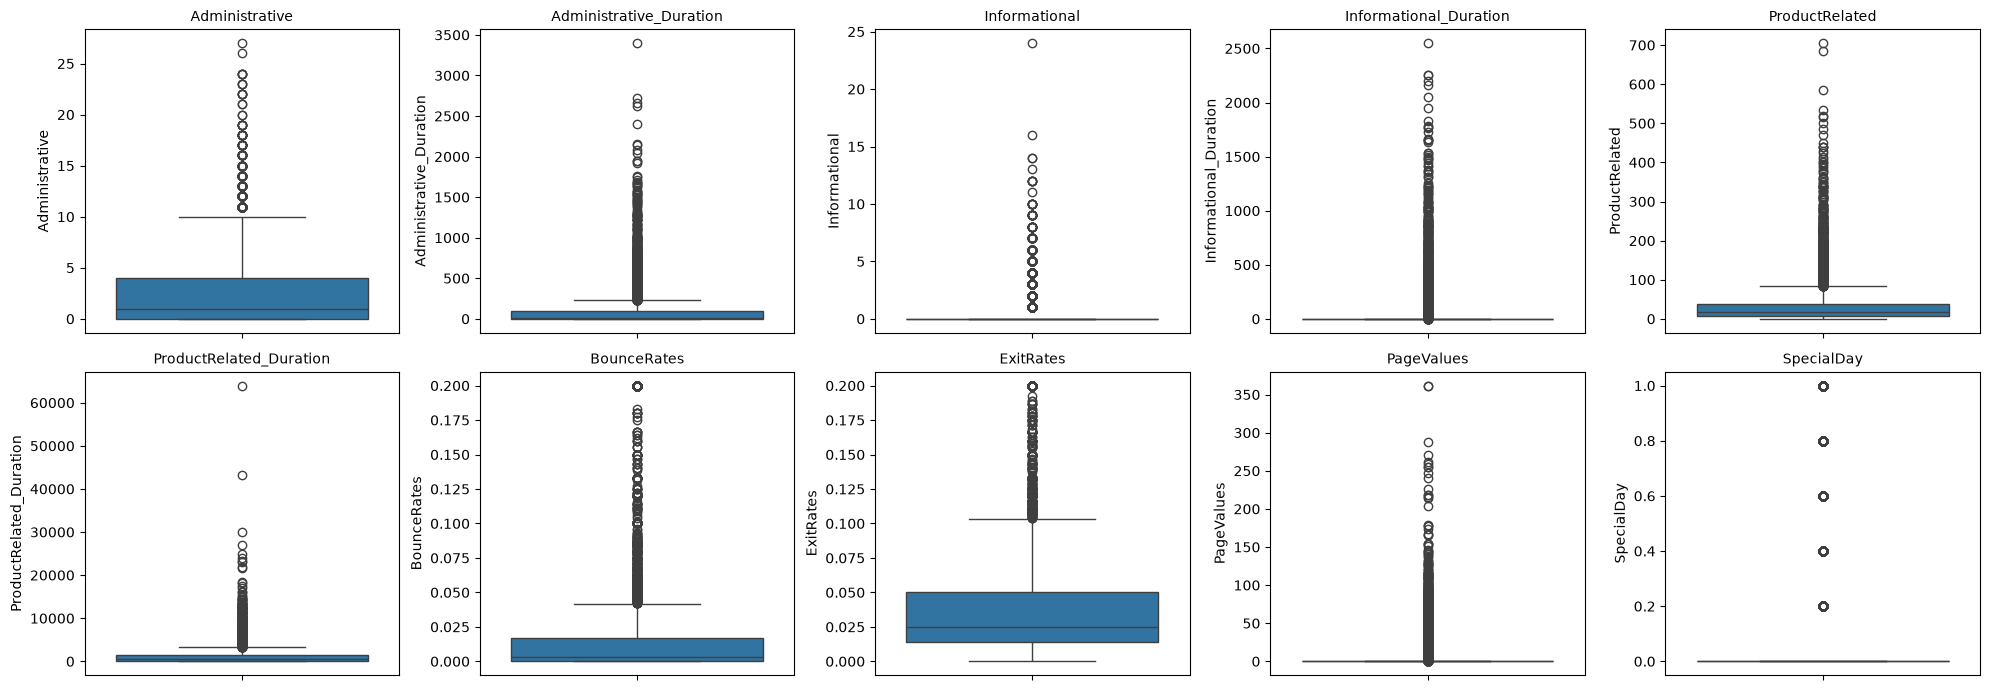

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, feat in zip(axes.flatten(), numeric_features):
    sns.boxplot(y=df[feat], ax=ax)
    ax.set_title(feat, fontsize=10)
plt.tight_layout()
plt.savefig('../results/figures/numeric_boxplots.png', dpi=120)
plt.show()


In [9]:
outlier_rows = []
for feat in numeric_features:
    q1 = df[feat].quantile(0.25)
    q3 = df[feat].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (df[feat] < lower) | (df[feat] > upper)
    outlier_rows.append({
        'feature': feat,
        'q1': round(q1, 2), 'q3': round(q3, 2), 'iqr': round(iqr, 2),
        'lower_bound': round(lower, 2), 'upper_bound': round(upper, 2),
        'n_outliers': int(mask.sum()),
        'pct_outliers': round(mask.sum() / len(df) * 100, 1),
    })

outlier_summary = pd.DataFrame(outlier_rows).set_index('feature')
outlier_summary.to_csv('../results/tables/eda_outliers.csv')
outlier_summary


,q1,q3,iqr,lower_bound,upper_bound,n_outliers,pct_outliers
feature,,,,,,,
Administrative,0.00,4.00,4.00,-6.00,10.00,404,3.3
Administrative_Duration,0.00,93.26,93.26,-139.88,233.14,1172,9.5
Informational,0.00,0.00,0.00,0.00,0.00,2631,21.3
Informational_Duration,0.00,0.00,0.00,0.00,0.00,2405,19.5
ProductRelated,7.00,38.00,31.00,-39.50,84.50,987,8.0
ProductRelated_Duration,184.14,1464.16,1280.02,-1735.89,3384.19,961,7.8
BounceRates,0.00,0.02,0.02,-0.03,0.04,1551,12.6
ExitRates,0.01,0.05,0.04,-0.04,0.10,1099,8.9
PageValues,0.00,0.00,0.00,0.00,0.00,2730,22.1


### Catatan Temuan: Outlier dan Anomali

Metode IQR (1,5x) menghasilkan proporsi outlier yang tampak besar (8-22%) pada beberapa fitur, tetapi
ini perlu dibaca dengan hati-hati karena sebagian besar fitur numerik pada dataset ini sangat
*zero-inflated* (mayoritas sesi mencatat nilai 0):

- **Informational, PageValues, SpecialDay**: median dan bahkan Q1/Q3 bernilai 0 (mayoritas pengunjung
  tidak membuka halaman informational, tidak memiliki page value tercatat, atau bukan sesi menjelang
  hari spesial). Akibatnya, IQR = 0 dan setiap nilai non-nol otomatis "melewati" batas IQR, sehingga
  hitungan outlier di sini (19-22%) **bukan indikasi anomali**, melainkan artefak dari distribusi yang
  memang sangat terkonsentrasi di nol. Nilai non-nol pada `PageValues` justru diketahui sebagai sinyal
  paling prediktif terhadap `Revenue` (dikonfirmasi pada bagian hubungan fitur-target di bawah), jadi
  menghapusnya sebagai "outlier" akan menghilangkan informasi paling penting dalam dataset.
- **Administrative_Duration, ProductRelated_Duration, BounceRates, ExitRates**: outlier di sini merepresentasikan
  sesi dengan durasi sangat lama atau bounce rate ekstrem. Ini kemungkinan besar merupakan perilaku
  pengunjung yang valid (sesi browsing panjang, atau sesi yang langsung ditinggalkan), bukan kesalahan
  input data, karena nilai-nilai ini masih dalam rentang yang masuk akal secara domain (durasi dalam
  detik, rate antara 0 dan 1).

**Implikasi untuk preprocessing/modeling:** outlier pada fitur numerik ini TIDAK akan dihapus/dipangkas
(*capping/trimming*), karena (a) sebagian adalah artefak zero-inflation, bukan anomali, dan (b) sebagian
lain adalah sinyal perilaku valid yang relevan terhadap target. Paper juga tidak menyebutkan langkah
outlier removal, sehingga mempertahankan nilai asli konsisten dengan pipeline yang direplikasi.
Standard scaling (bukan robust scaling) yang dipakai paper tetap dipertahankan pada replikasi, meski
secara teoretis kurang ideal untuk distribusi seskew ini, karena mengubahnya akan menyimpang dari
metodologi asli yang sedang direplikasi.

## Distribusi Fitur Numerik (histogram)

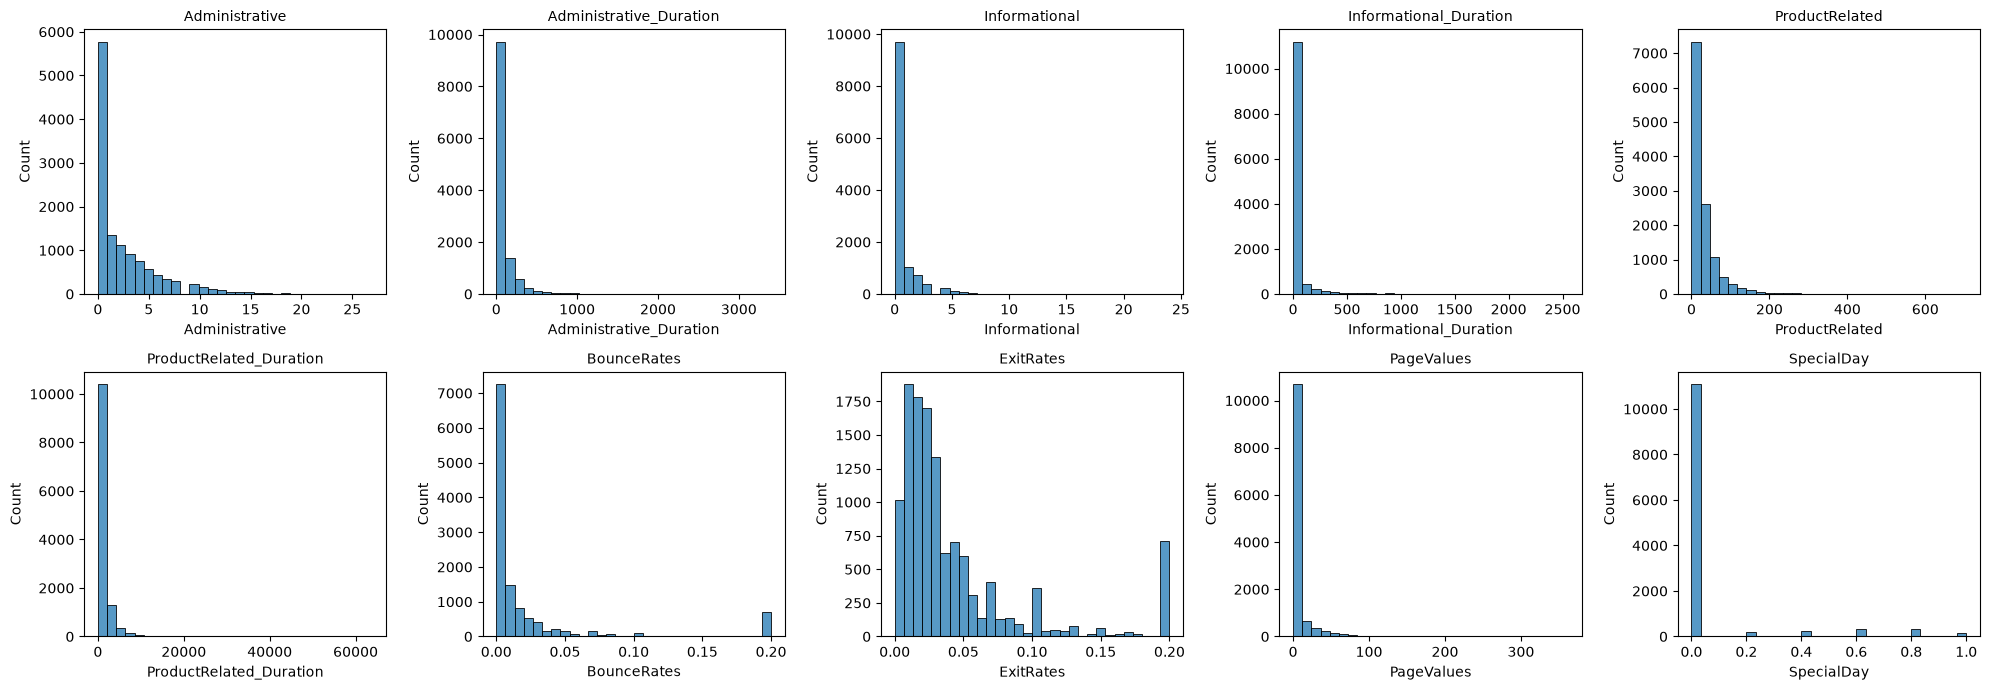

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, feat in zip(axes.flatten(), numeric_features):
    sns.histplot(df[feat], bins=30, ax=ax)
    ax.set_title(feat, fontsize=10)
plt.tight_layout()
plt.savefig('../results/figures/numeric_histograms.png', dpi=120)
plt.show()

## Hubungan Fitur-Target, Korelasi, dan Potensi Leakage

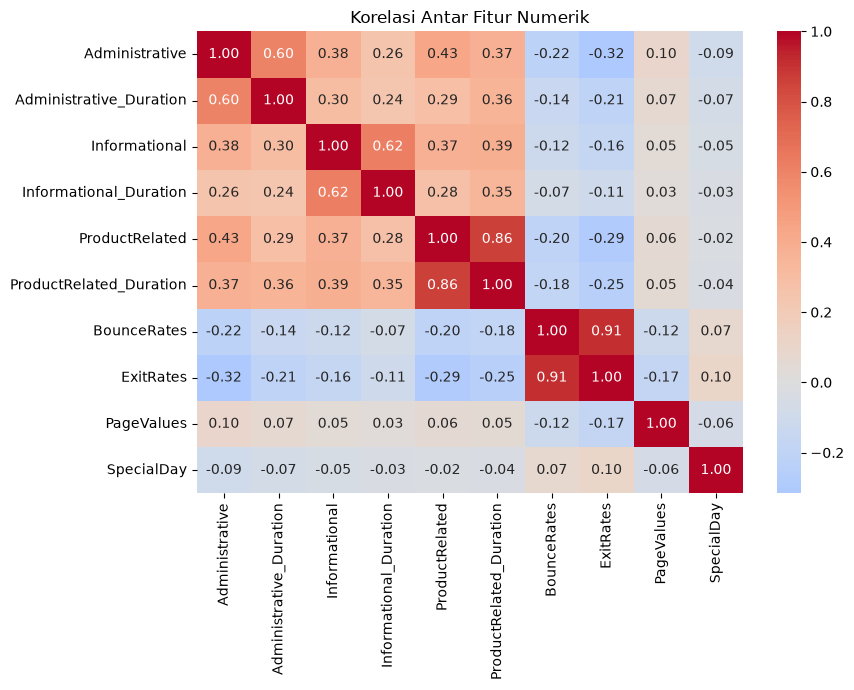

In [11]:
corr = df[numeric_features].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Korelasi Antar Fitur Numerik')
plt.tight_layout()
plt.savefig('../results/figures/correlation_heatmap.png', dpi=120)
plt.show()


In [12]:
import itertools

print('Pasangan fitur numerik dengan |korelasi| > 0.6 (kandidat redundansi):')
high_corr_pairs = []
for a, b in itertools.combinations(numeric_features, 2):
    r = corr.loc[a, b]
    if abs(r) > 0.6:
        high_corr_pairs.append({'feature_a': a, 'feature_b': b, 'correlation': round(r, 2)})
        print(f'{a} vs {b}: {r:.2f}')

pd.DataFrame(high_corr_pairs).to_csv('../results/tables/eda_high_correlation_pairs.csv', index=False)


Pasangan fitur numerik dengan |korelasi| > 0.6 (kandidat redundansi):
Administrative vs Administrative_Duration: 0.60
Informational vs Informational_Duration: 0.62
ProductRelated vs ProductRelated_Duration: 0.86
BounceRates vs ExitRates: 0.91


In [13]:
df['Revenue_num'] = df['Revenue'].astype(int)
target_corr = df[numeric_features + ['Revenue_num']].corr()['Revenue_num'].drop('Revenue_num').sort_values(ascending=False)
print('Korelasi tiap fitur numerik dengan Revenue (diurutkan):')
print(target_corr.round(3))

target_corr.round(3).to_csv('../results/tables/eda_feature_target_correlation.csv', header=['correlation_with_revenue'])


Korelasi tiap fitur numerik dengan Revenue (diurutkan):
PageValues                 0.493
ProductRelated             0.159
ProductRelated_Duration    0.152
Administrative             0.139
Informational              0.095
Administrative_Duration    0.094
Informational_Duration     0.070
SpecialDay                -0.082
BounceRates               -0.151
ExitRates                 -0.207
Name: Revenue_num, dtype: float64


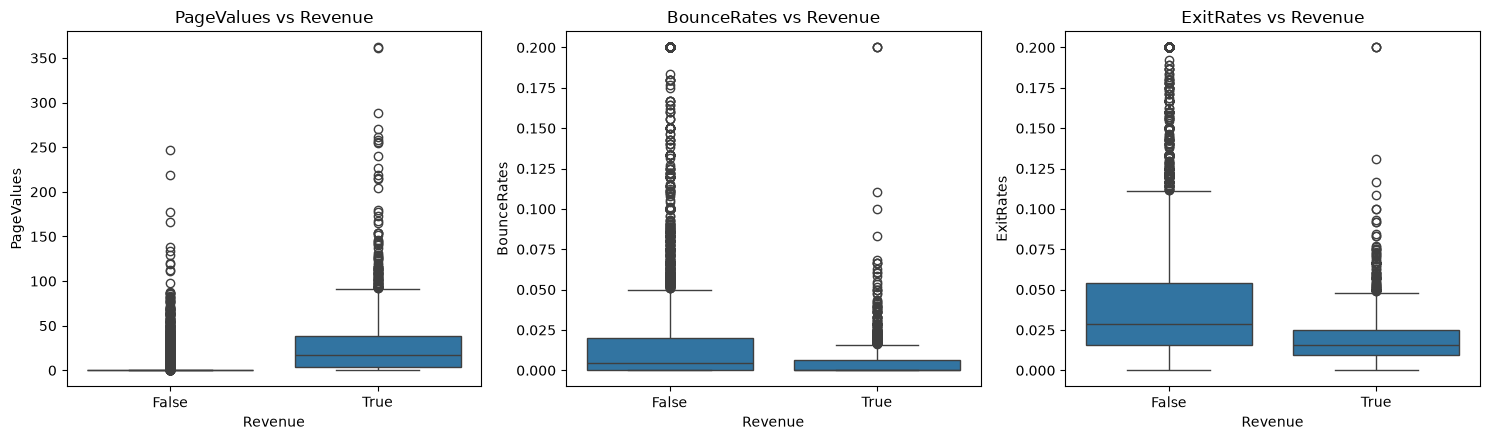

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, feat in zip(axes, ['PageValues', 'BounceRates', 'ExitRates']):
    sns.boxplot(x='Revenue', y=feat, data=df, ax=ax)
    ax.set_title(f'{feat} vs Revenue')
plt.tight_layout()
plt.savefig('../results/figures/feature_vs_target_boxplots.png', dpi=120)
plt.show()


In [15]:
print('Revenue rate (%) per Month:')
print((df.groupby('Month')['Revenue'].mean() * 100).round(1).sort_values(ascending=False))
print()
print('Revenue rate (%) per VisitorType:')
print((df.groupby('VisitorType')['Revenue'].mean() * 100).round(1).sort_values(ascending=False))
print()
print('Revenue rate (%) per Weekend:')
print((df.groupby('Weekend')['Revenue'].mean() * 100).round(1))


Revenue rate (%) per Month:
Month
Nov     25.4
Oct     20.9
Sep     19.2
Aug     17.6
Jul     15.3
Dec     12.5
May     10.9
June    10.1
Mar     10.1
Feb      1.6
Name: Revenue, dtype: float64

Revenue rate (%) per VisitorType:
VisitorType
New_Visitor          24.9
Other                18.8
Returning_Visitor    13.9
Name: Revenue, dtype: float64

Revenue rate (%) per Weekend:
Weekend
False    14.9
True     17.4
Name: Revenue, dtype: float64


### Catatan Temuan: Hubungan Fitur-Target dan Korelasi

**Fitur paling terkait dengan Revenue:** `PageValues` punya korelasi jauh lebih tinggi (r=0,49) dibanding
fitur numerik lain (semua di bawah 0,21). Ini konsisten dengan temuan paper yang menyebut `PageValues`
sebagai fitur paling berpengaruh dalam struktur decision tree. `ExitRates` dan `BounceRates` berkorelasi
negatif dengan Revenue (r=-0,21 dan -0,15), masuk akal karena bounce/exit tinggi berarti pengunjung cepat
meninggalkan situs tanpa membeli.

Secara kategorikal, `Month = November` punya tingkat konversi tertinggi (25,4%, kemungkinan terkait
Black Friday/Cyber Monday), jauh di atas `Februari` (1,6%). `VisitorType = New_Visitor` (24,9%) justru
konversi lebih tinggi dibanding `Returning_Visitor` (13,9%), menarik karena intuisi umum biasanya
sebaliknya. Kedua temuan ini konsisten dengan aturan bisnis yang diekstrak paper dari decision tree
(`Month_November`, tipe pengunjung).

**Redundansi antar fitur:** ditemukan 4 pasang fitur numerik dengan korelasi tinggi (>0,6):
`Administrative` vs `Administrative_Duration` (0,60), `Informational` vs `Informational_Duration` (0,62),
`ProductRelated` vs `ProductRelated_Duration` (0,86), dan `BounceRates` vs `ExitRates` (0,91). Pola ini
masuk akal karena jumlah halaman dan durasi kunjungan pada kategori yang sama pasti berkorelasi, begitu
juga BounceRates dan ExitRates yang secara definisi serupa (bounce adalah kasus khusus exit). Redundansi
ini menjadi salah satu alasan metodologis kenapa seleksi fitur (χ², dilakukan paper) relevan: sebagian
fitur menyumbang informasi yang tumpang tindih terhadap model.

**Potensi leakage:** `PageValues`, `BounceRates`, dan `ExitRates` dihitung dari perilaku SELAMA sesi
berlangsung (bukan hasil akhir sesi seperti Revenue), sehingga secara konseptual bukan target leakage
langsung -- semuanya tersedia sebelum keputusan pembelian final terjadi, sesuai skenario prediksi dini
yang diklaim paper. Namun ada nuansa penting: `PageValues` pada beberapa implementasi Google Analytics
dihitung berdasarkan rata-rata nilai halaman relatif terhadap SEMUA sesi historis situs (termasuk sesi
yang berujung konversi), sehingga jika nilai ini dihitung ULANG memakai data yang mencakup periode setelah
sesi berlangsung, ada risiko leakage tidak langsung (informasi dari masa depan relatif terhadap sesi
tersebut ikut menyusup ke fitur). Paper tidak membahas isu ini sama sekali. Untuk keperluan replikasi,
`PageValues` diperlakukan sebagai fitur pre-komputasi yang given (sebagaimana adanya di dataset), tetapi
risiko ini didokumentasikan sebagai limitasi (dibahas lebih lanjut di bagian Diskusi laporan). Bentuk
leakage yang lebih konkret dan bisa diperbaiki dalam replikasi ini justru ada di tahap PIPELINE
(preprocessing yang di-fit ke seluruh dataset sebelum split), yang akan diaudit di notebook berikutnya.

## Ringkasan Temuan EDA dan Implikasi untuk Preprocessing/Modeling

| # | Temuan | Bukti | Implikasi untuk Preprocessing/Modeling |
|---|---|---|---|
| 1 | Kelas target sangat imbalanced (84,5% vs 15,5%) | `eda_duplicates`/cell distribusi Revenue awal | Perlu metrik evaluasi imbalance-aware (auROC, auPR, MCC), bukan hanya akurasi; perlu SMOTE/undersampling yang di-fit HANYA pada data train |
| 2 | `PageValues` adalah fitur numerik paling prediktif (r=0,49 dengan Revenue), sisanya jauh lebih lemah | Tabel korelasi fitur-target | Model non-linear (tree-based, XGBoost) yang bisa menangkap threshold PageValues cenderung unggul; perlu waspada training/serving skew jika PageValues dihitung ulang di production |
| 3 | Sebagian besar fitur numerik sangat *zero-inflated* dan skewed (Informational, PageValues, SpecialDay) | Boxplot & IQR outlier check | Standard scaling (dipakai paper) kurang ideal secara teori untuk distribusi ini, tapi dipertahankan demi kesetiaan replikasi; outlier TIDAK dihapus karena sebagian adalah sinyal penting |
| 4 | Redundansi tinggi antar fitur (BounceRates-ExitRates r=0,91; ProductRelated-ProductRelated_Duration r=0,86) | Correlation heatmap | Mendukung relevansi seleksi fitur χ² paper untuk mengurangi redundansi; namun proses χ² pada replikasi harus di-fit hanya di data train agar tidak leakage |
| 5 | Duplikat baris (1,01%) seluruhnya di kelas mayoritas, kemungkinan koinsidensi sesi generik bukan error | Analisis duplikat | Baris dipertahankan; tidak mengubah N observasi (12.330) di seluruh pipeline |
| 6 | `Month` di dataset hanya 10 level aktif (bukan 12), tapi total fitur pasca-encoding tetap cocok dengan klaim paper (28 fitur) | Cross-check Tabel 3 paper | Bukan penyimpangan; one-hot encoding tetap dilakukan hanya pada `Month` dan `VisitorType`, sesuai rekonstruksi skema paper |
| 7 | `Month_November` dan `VisitorType=New_Visitor` punya tingkat konversi jauh di atas rata-rata | Crosstab kategorikal vs Revenue | Konsisten dengan business rules paper dari decision tree; mendukung keputusan tidak melakukan transformasi tambahan pada fitur kategorikal ini |

**Kesimpulan implikasi utama:** dataset ini layak untuk direplikasi sesuai skema paper (one-hot encoding
terbatas pada Month & VisitorType, standard scaling, seleksi fitur χ², SMOTE/undersampling), TANPA
perlu penghapusan data (duplikat maupun outlier). Risiko metodologis terbesar yang perlu dikoreksi ada
pada URUTAN pipeline (apakah preprocessing di-fit sebelum atau sesudah train-test split), bukan pada
kualitas data itu sendiri -- ini menjadi fokus audit metodologi pada tahap berikutnya.

In [16]:
print('EDA selesai. File tersimpan:')
print('- results/tables/eda_numeric_summary.csv')
print('- results/tables/eda_categorical_summary.csv')
print('- results/figures/class_distribution.png')
print('- results/figures/numeric_histograms.png')

EDA selesai. File tersimpan:
- results/tables/eda_numeric_summary.csv
- results/tables/eda_categorical_summary.csv
- results/figures/class_distribution.png
- results/figures/numeric_histograms.png
